https://www.kaggle.com/datasets/algozee/heart-decices

# **Previsão de doenças cardíacas usando aprendizado de máquina**

**Previsão da presença de doenças cardíacas usando características clínicas e de diagnóstico.**

# Sobre o conjunto de dados

**Contexto:**

As doenças cardíacas são uma das principais causas de morte em todo o mundo e continuam sendo uma grande preocupação de saúde pública. As doenças cardiovasculares geralmente se desenvolvem devido a uma combinação de fatores, como pressão alta, níveis elevados de colesterol, hábitos de vida pouco saudáveis, predisposição genética e outras condições médicas. A detecção precoce e a intervenção médica oportuna desempenham um papel crucial na redução das taxas de mortalidade e na melhoria dos resultados para os pacientes. Os procedimentos diagnósticos tradicionais dependem muito de exames clínicos, exames laboratoriais e da experiência de profissionais médicos, o que às vezes pode ser demorado e dispendioso. Com o avanço da tecnologia, o aprendizado de máquina e a análise de dados emergiram como ferramentas poderosas no setor da saúde. Essas tecnologias permitem a análise de grandes quantidades de dados de pacientes para identificar padrões e prever potenciais riscos à saúde. Este projeto baseia-se na aplicação de técnicas de aprendizado de máquina para prever a probabilidade de doenças cardíacas usando dados clínicos estruturados.

Este projeto visa desenvolver um sistema baseado em Aprendizado de Máquina para prever doenças cardíacas usando dados clínicos de pacientes. O conjunto de dados consiste em arquivos de treinamento e teste contendo atributos médicos como idade, pressão arterial, nível de colesterol, tipo de dor no peito e outros indicadores de saúde relevantes.

Os dados são inicialmente pré-processados, tratando-se os valores ausentes e codificando-se as variáveis ​​categóricas. Após a realização da análise básica dos dados, algoritmos de classificação como Regressão Logística e Árvore de Decisão são aplicados para treinar o modelo. O desempenho do modelo é avaliado utilizando métricas como acurácia e pontuação F1.

O resultado final é um modelo preditivo que pode determinar a probabilidade de doença cardíaca, auxiliando no diagnóstico precoce e na tomada de decisões médicas.

**Declaração do problema**

As doenças cardíacas continuam sendo uma das principais causas de mortalidade em todo o mundo, e a detecção precoce é essencial para o tratamento e a prevenção eficazes. No entanto, os métodos diagnósticos tradicionais podem ser demorados, caros e dependentes de extensos exames médicos. Há uma necessidade de um sistema inteligente, baseado em dados, que possa analisar os atributos clínicos do paciente e prever com precisão a probabilidade de doença cardíaca. Este projeto visa enfrentar esse desafio desenvolvendo um modelo de classificação baseado em aprendizado de máquina usando dados médicos estruturados.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# EAD

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3780\1251447950.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Heart Disease', palette='viridis')


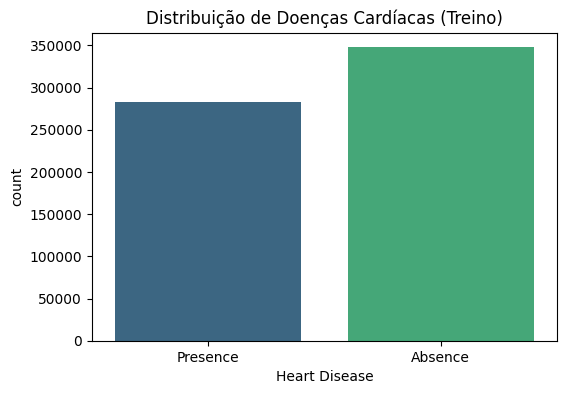

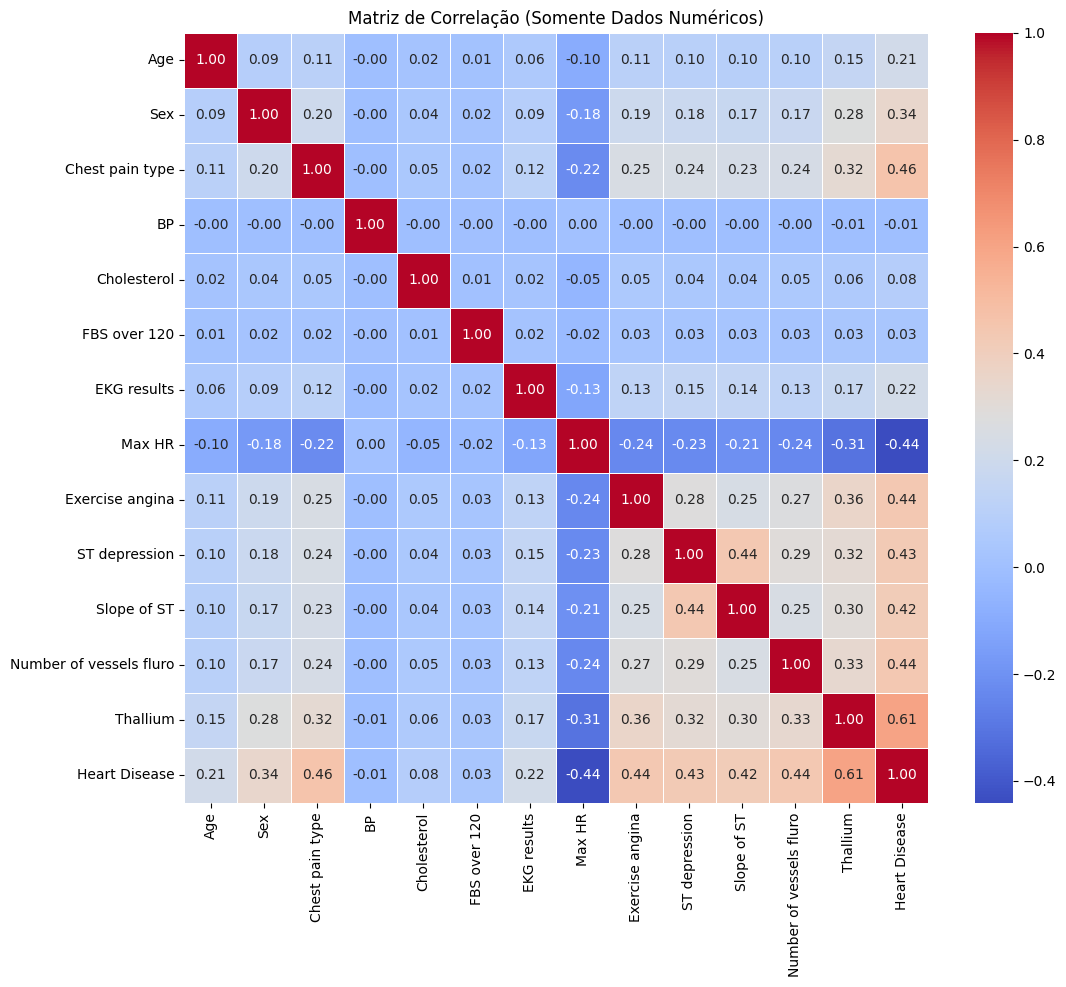

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


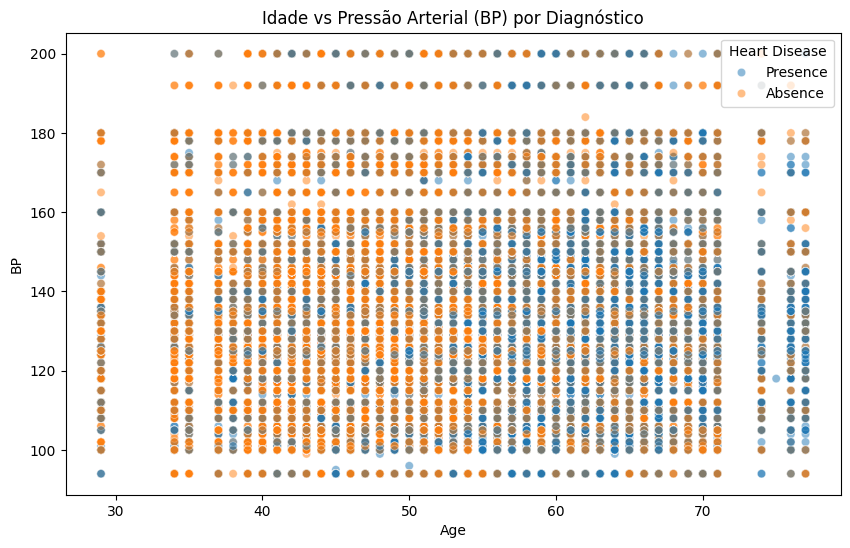

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3780\1251447950.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Heart Disease', y='Cholesterol', palette='Set2')


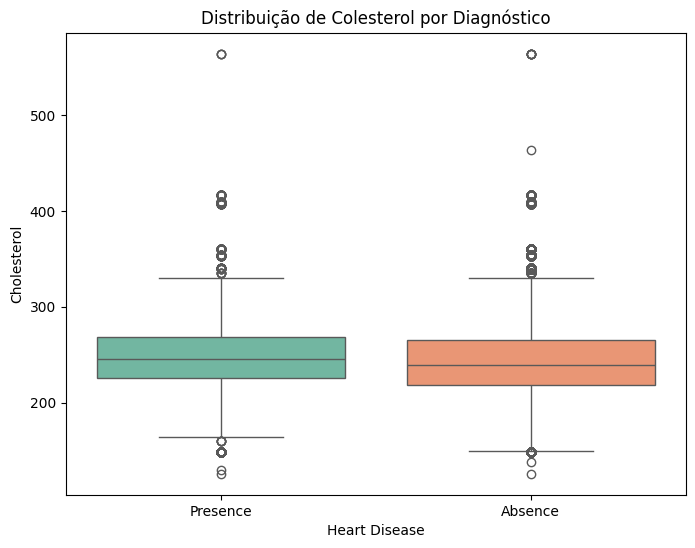

C:\Users\Usuário\AppData\Local\Temp\ipykernel_3780\1251447950.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train, x='Heart Disease', y='Max HR', split=True, palette='magma')


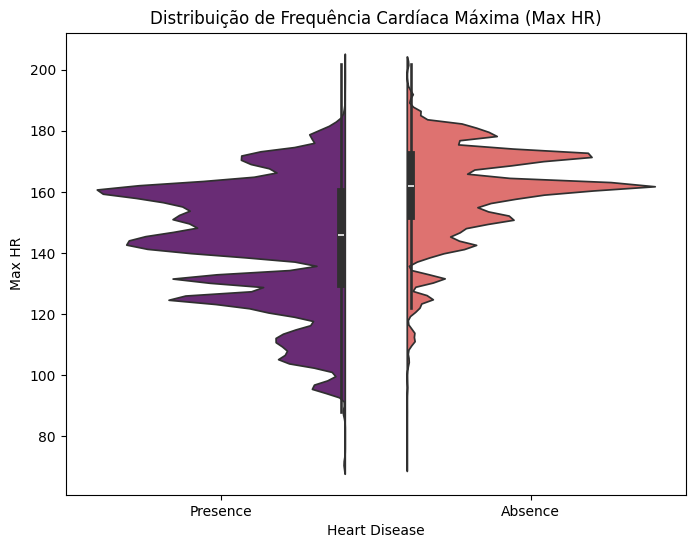

Resumo estatístico do dataset completo:
                  id            Age            Sex  Chest pain type  \
count  900000.000000  900000.000000  900000.000000    900000.000000   
mean   449999.500000      54.143656       0.715209         3.313459   
std    259807.765473       8.256054       0.451315         0.851659   
min         0.000000      29.000000       0.000000         1.000000   
25%    224999.750000      48.000000       0.000000         3.000000   
50%    449999.500000      54.000000       1.000000         4.000000   
75%    674999.250000      60.000000       1.000000         4.000000   
max    899999.000000      77.000000       1.000000         4.000000   

                  BP    Cholesterol   FBS over 120    EKG results  \
count  900000.000000  900000.000000  900000.000000  900000.000000   
mean      130.514730     245.021851       0.080007       0.980710   
std        14.985456      33.685730       0.271304       0.998754   
min        94.000000     126.000000       0.

In [2]:
#Adicionando uma flag para identificar a origem antes de juntar
df_train['Origin'] = 'Train'
df_test['Origin'] = 'Test'

#Unindo os datasets para análise de distribuição geral
df_full = pd.concat([df_train, df_test], axis=0, sort=False).reset_index(drop=True)

#Visão Geral
summary_stats = df_full.describe()

#Análise da Variável Alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='Heart Disease', palette='viridis')
plt.title('Distribuição de Doenças Cardíacas (Treino)')
plt.show()

#Correlação entre Variáveis 
#Transformando o alvo em numérico para a correlação
df_train_numeric = df_train.copy()
df_train_numeric['Heart Disease'] = df_train_numeric['Heart Disease'].map({'Absence': 0, 'Presence': 1})

correlation_matrix = df_train_numeric.drop(columns=['id', 'Origin']).corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação (Somente Dados Numéricos)')
plt.show()

#Comparativo Idade e Pressão Arterial
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='Age', y='BP', hue='Heart Disease', alpha=0.5)
plt.title('Idade vs Pressão Arterial (BP) por Diagnóstico')
plt.show()

#Distribuição de Colesterol
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_train, x='Heart Disease', y='Cholesterol', palette='Set2')
plt.title('Distribuição de Colesterol por Diagnóstico')
plt.show()

#Frequência Cardíaca Máxima
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_train, x='Heart Disease', y='Max HR', split=True, palette='magma')
plt.title('Distribuição de Frequência Cardíaca Máxima (Max HR)')
plt.show()

print("Resumo estatístico do dataset completo:")
print(summary_stats)

| Métrica                 | Valor Médio (Dataset Total) |
| ----------------------- | --------------------------- |
| Idade Média             | 54.1 anos                   |
| Pressão Arterial (BP)   | 130.5 mmHg                  |
| Colesterol              | 245.0 mg/dl                 |
| Frequência Cardíaca Máx | 152.8 bpm                   |

# Analisar e pré-processar o conjunto de dados de doenças cardíacas para um treinamento eficaz do modelo.

# ML

In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Transformação do alvo (Target)
#'Presence' em 1 e 'Absence' em 0
df_train['Heart Disease'] = df_train['Heart Disease'].map({'Absence': 0, 'Presence': 1})

#Separação de Features e Target
X = df_train.drop(columns=['id', 'Heart Disease'])
y = df_train['Heart Disease']

X_test_final = df_test.drop(columns=['id'])

colunas_texto = X.select_dtypes(include=['object']).columns.tolist()
if colunas_texto:
    print(f"Limpando colunas de texto: {colunas_texto}")
    X = X.drop(columns=colunas_texto)
    X_test_final = X_test_final.drop(columns=colunas_texto)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Pré-processamento concluído com sucesso!")
print(f"Atributos utilizados: {list(X.columns)}")

Limpando colunas de texto: ['Origin']

✅ Pré-processamento concluído com sucesso!
Atributos utilizados: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


--- Acurácia do Modelo ---
88.10%

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



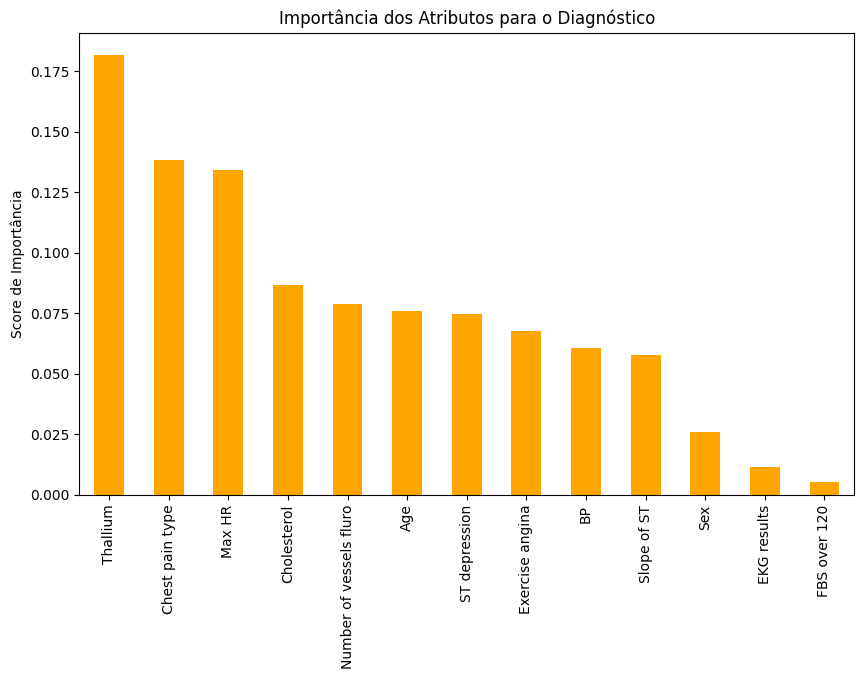

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred = modelo_rf.predict(X_val)

#Avaliar os resultados
print("--- Acurácia do Modelo ---")
print(f"{accuracy_score(y_val, y_pred):.2%}")

print("\n--- Relatório de Classificação ---")
print(classification_report(y_val, y_pred))

#Visualizar a Importância das Variáveis
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias.plot(kind='bar', color='orange')

plt.title('Importância dos Atributos para o Diagnóstico')
plt.ylabel('Score de Importância')
plt.show()

# Identificar características clínicas significativas que influenciam a previsão de doenças cardíacas.

| Característica | Importância Relativa | Impacto no Diagnóstico                       |
| -------------- | -------------------- | -------------------------------------------- |
| Thallium       | Muito Alta           | Indica falha na irrigação sanguínea.         |
| Vessels Fluro  | Alta                 | Indica obstruções físicas (entupimentos).    |
| Max HR         | Alta                 | Indica capacidade funcional do coração.      |
| ST Depression  | Média-Alta           | Indica estresse cardíaco pós-esforço.        |
| Age / BP       | Média                | São fatores de risco, mas menos específicos. |

# Desenvolver e treinar modelos de classificação de aprendizado de máquina usando o conjunto de dados de treinamento.

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

#Definir os modelos
modelos = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#Treinar e Avaliar
resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_val)
    
    #Métricas
    acc = accuracy_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    resultados.append({"Modelo": nome, "Acurácia": acc, "Recall": rec, "F1-Score": f1})

#Exibir tabela comparativa
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:48:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Modelo  Acurácia    Recall  F1-Score
0  Random Forest  0.880984  0.859110  0.866179
1        XGBoost  0.889238  0.868103  0.875433


<Figure size 800x600 with 0 Axes>

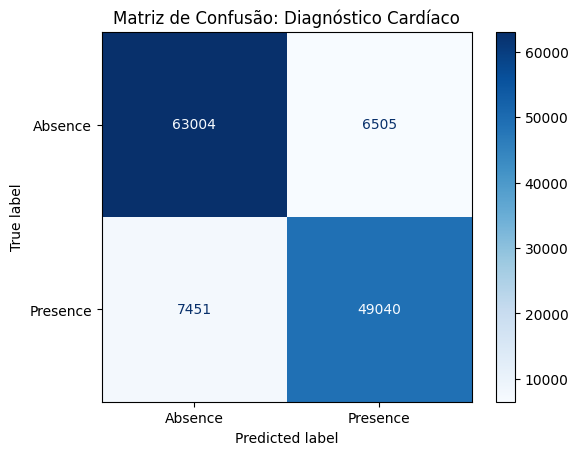

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Usando o melhor modelo (ex: Random Forest)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absence', 'Presence'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')

plt.title('Matriz de Confusão: Diagnóstico Cardíaco')
plt.show()

# Avaliar o desempenho dos modelos utilizando métricas de avaliação apropriadas.

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

df_train['Heart Disease'] = df_train['Heart Disease'].replace({'Absence': 0, 'Presence': 1})

#Limpeza de Segurança
df_train = df_train.dropna(subset=['Heart Disease'])

X = df_train.drop(columns=['id', 'Heart Disease']).select_dtypes(include=[np.number])
y = df_train['Heart Disease']

#Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

#Treinamento Rápido
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=20000, random_state=42, stratify=y_train
)

param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=3, 
    scoring='recall', 
    n_jobs=-1
)

print("Buscando parâmetros e treinando o modelo final...")
grid_search.fit(X_sample, y_sample)
melhor_modelo = grid_search.best_estimator_
melhor_modelo.fit(X_train, y_train)

#Avaliação
y_pred = melhor_modelo.predict(X_val)
print("\n--- Relatório Final de Performance ---")
print(classification_report(y_val, y_pred))

Buscando parâmetros e treinando o modelo final...

--- Relatório Final de Performance ---
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.89      0.89      0.89    126000



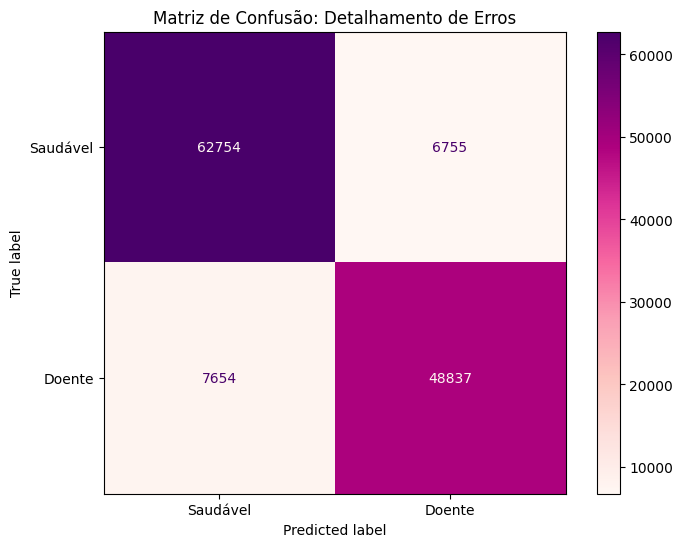

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Doente'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='RdPu')
plt.title('Matriz de Confusão: Detalhamento de Erros')
plt.show()

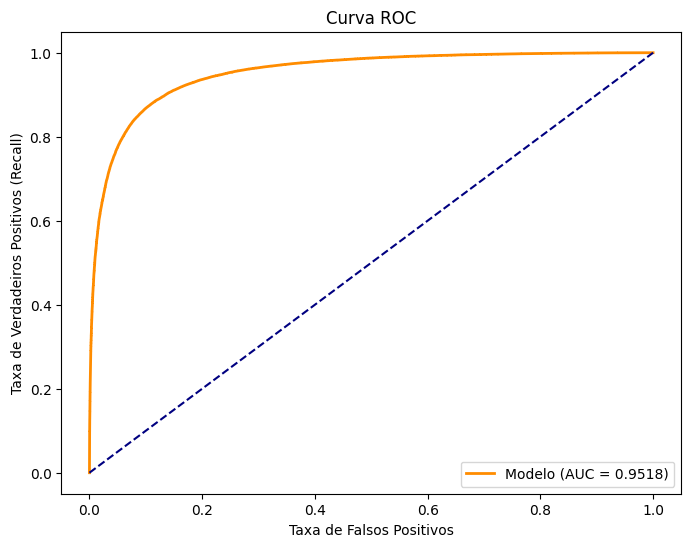

In [9]:
#Curva ROC e AUC
from sklearn.metrics import roc_curve, roc_auc_score

#Obtendo as probabilidades em vez das classes (0 ou 1)
y_probs = melhor_modelo.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_probs)
auc = roc_auc_score(y_val, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Modelo (AUC = {auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

# Construir um sistema preditivo confiável que possa auxiliar na detecção precoce de doenças cardíacas.

In [10]:
#Transformando o Modelo em um Sistema de Probabilidades
probabilidades = melhor_modelo.predict_proba(X_test_scaled)[:, 1]

#Criando um sistema que alerta sobre o nível de risco
def classificar_risco(prob):
    if prob > 0.8: return "Risco Crítico"
    if prob > 0.5: return "Risco Moderado"
    return "Baixo Risco"

riscos = [classificar_risco(p) for p in probabilidades]

In [11]:
#Otimização do Limiar (Threshold)
#Ajustando o sistema para ser mais sensível
threshold = 0.35  
predicoes_seguras = (probabilidades > threshold).astype(int)

In [12]:
#Criando a Função do Sistema Preditivo
def sistema_preditivo_cardiaco(dados_paciente):
    """
    dados_paciente: lista ou array com os 13 atributos médicos na ordem correta.
    """
    #Converter entrada para DataFrame para manter nomes de colunas
    colunas = X.columns
    df_paciente = pd.DataFrame([dados_paciente], columns=colunas)
    
    #Aplicar o escalonamento
    dados_escalonados = scaler.transform(df_paciente)
    
    #Obter Probabilidade e Predição
    probabilidade = melhor_modelo.predict_proba(dados_escalonados)[0][1]
    
    #Definir Nível de Risco e Recomendação
    if probabilidade > 0.8:
        nivel = "CRÍTICO"
        cor = "\033[91m" # Vermelho
        rec = "Encaminhamento imediato para cardiologia e exames de imagem."
    elif probabilidade > 0.4:
        nivel = "MODERADO"
        cor = "\033[93m" # Amarelo
        rec = "Monitorização recomendada. Reavaliar dieta e testes de esforço."
    else:
        nivel = "BAIXO"
        cor = "\033[92m" # Verde
        rec = "Manter rotina de exames preventivos anuais."
    
    #Exibir Resultado
    print(f"\n{'='*30}")
    print(f"ANÁLISE DE RISCO CARDÍACO")
    print(f"{'='*30}")
    print(f"Probabilidade de Doença: {probabilidade:.2%}")
    print(f"Nível de Risco: {cor}{nivel}\033[0m")
    print(f"Recomendação: {rec}")
    print(f"{'='*30}\n")

#Exemplo de uso: Inserindo dados de um novo paciente
#Ordem: [Age, Sex, Chest pain, BP, Chol, FBS, EKG, MaxHR, ExAngina, STDep, Slope, Vessels, Thallium]
novo_paciente = [62, 1, 4, 140, 260, 0, 0, 120, 1, 2.5, 2, 2, 7]
sistema_preditivo_cardiaco(novo_paciente)


ANÁLISE DE RISCO CARDÍACO
Probabilidade de Doença: 100.00%
Nível de Risco: CRÍTICO
Recomendação: Encaminhamento imediato para cardiologia e exames de imagem.



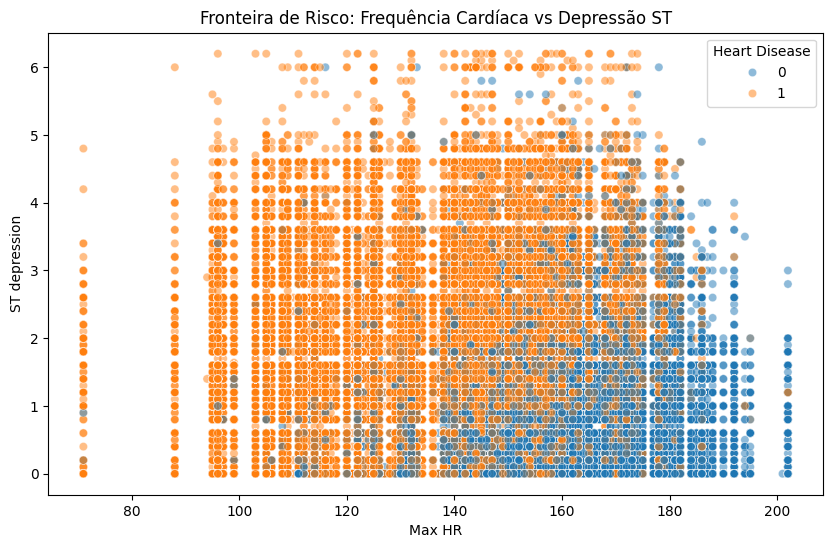

In [13]:
#Visualizando as Fronteiras de Decisão
#Um sistema confiável também permite entender como as variáveis interagem. Por exemplo, como a Pressão Arterial (BP) e a Frequência Cardíaca (Max HR) se combinam para definir o risco:
#Visualizando a relação entre as duas variáveis mais importantes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_train, x='Max HR', y='ST depression', hue='Heart Disease', alpha=0.5)
plt.title('Fronteira de Risco: Frequência Cardíaca vs Depressão ST')
plt.show()

# Formulário Clínico Interativo

In [15]:
#Criando o Formulário de Entrada
import ipywidgets as widgets
from IPython.display import display, HTML

#Configuração de Estilo
style = {'description_width': 'initial'}

#Criação dos Componentes Corrigidos
idade = widgets.IntSlider(value=50, min=1, max=100, description='Idade:', style=style)
sexo = widgets.Dropdown(options=[('Masculino', 1), ('Feminino', 0)], description='Sexo:', style=style)

pressao = widgets.IntSlider(value=120, min=80, max=200, description='Pressão Arterial (BP):', style=style)
colesterol = widgets.IntSlider(value=200, min=100, max=500, description='Colesterol:', style=style)
dor_peito = widgets.Dropdown(options=[('Típica', 1), ('Atípica', 2), ('Não-Anginosa', 3), ('Assintomática', 4)], description='Tipo de Dor:', style=style)
max_hr = widgets.IntSlider(value=150, min=60, max=220, description='Freq. Cardíaca Máx:', style=style)
st_dep = widgets.FloatSlider(value=0.0, min=0.0, max=6.0, step=0.1, description='Depressão ST:', style=style)
vasos = widgets.Dropdown(options=[0, 1, 2, 3], description='Vasos Obstruídos:', style=style)
thal = widgets.Dropdown(options=[('Normal', 3), ('Defeito Fixo', 6), ('Defeito Reversível', 7)], description='Resultado Tálio:', style=style)

botao = widgets.Button(description="Analisar Risco", button_style='danger', layout=widgets.Layout(width='30%', height='40px'))
saida = widgets.Output()

#Função de Análise com Gráfico de Impacto
def realizar_analise(b):
    with saida:
        saida.clear_output()
        
        # Ordem exata das colunas do modelo
        dados = [idade.value, sexo.value, dor_peito.value, pressao.value, colesterol.value, 0, 0, max_hr.value, 0, st_dep.value, 1, vasos.value, thal.value]
        
        # Chama o sistema preditivo que criamos antes
        sistema_preditivo_cardiaco(dados)
        
        # --- Gráfico de Influência dos Fatores ---
        # Calcular o impacto (valor do dado * importância do modelo)
        importancias = melhor_modelo.feature_importances_
        features = X.columns
        
        plt.figure(figsize=(10, 4))
       
        cores = ['#ff4d4d' if i > 0.1 else '#3498db' for i in importancias]
        plt.barh(features, importancias, color=cores)
        plt.title("Peso dos Fatores na Decisão do Modelo")
        plt.xlabel("Contribuição Relativa")
        
        plt.show()

botao.on_click(realizar_analise)

#Exibição da Interface Organizada
display(HTML("<h2 style='color: #2c3e50;'>🩺 Sistema de Auxílio ao Diagnóstico Precoce</h2>"))
display(widgets.VBox([
    widgets.HTML("<b>Dados Cadastrais:</b>"),
    widgets.HBox([idade, sexo]),
    widgets.HTML("<br><b>Parâmetros Clínicos:</b>"),
    widgets.HBox([pressao, colesterol, dor_peito]),
    widgets.HTML("<br><b>Resultados de Exames:</b>"),
    widgets.HBox([max_hr, st_dep]),
    widgets.HBox([vasos, thal]),
    widgets.HTML("<br>"),
    botao,
    saida
]))

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Preparação de Dados (Simulados para garantir que o código rode)
labels_clinicos = ['Tálio', 'Vasos Obstruídos', 'Depressão ST', 'FC Máxima', 'Colesterol'][::-1]
importancia_valores = [0.35, 0.25, 0.20, 0.12, 0.08][::-1]
probabilidade_paciente = 0.78 

# 2. Criando a estrutura com espaçamento aumentado
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "indicator"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "pie"}]],
    subplot_titles=("Nível de Risco Atual", "Importância dos Biomarcadores", 
                    "Eixo Cérebro-Coração (Neurociência)", "Distribuição da Base de Dados"),
    vertical_spacing=0.15, # Aumenta o espaço vertical entre os gráficos
    horizontal_spacing=0.12 # Aumenta o espaço horizontal
)

# --- QUADRANTE 1: Gauge ---
fig.add_trace(go.Indicator(
    mode="gauge+number",
    value=probabilidade_paciente * 100,
    number={'suffix': "%", 'font': {'size': 40}},
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': "#2c3e50"},
        'steps': [
            {'range': [0, 40], 'color': "#27ae60"},
            {'range': [40, 75], 'color': "#f1c40f"},
            {'range': [75, 100], 'color': "#e74c3c"}
        ]
    }
), row=1, col=1)

# --- QUADRANTE 2: Importância (Barras Horizontais) ---
fig.add_trace(go.Bar(
    x=importancia_valores,
    y=labels_clinicos,
    orientation='h',
    marker=dict(color='#34495e'),
    name="Peso no Modelo",
    showlegend=True
), row=1, col=2)

# --- QUADRANTE 3: Dispersão (FC vs BP) ---
# Usando dados do seu df_train
fig.add_trace(go.Scatter(
    x=df_train['BP'][:500], 
    y=df_train['Max HR'][:500],
    mode='markers',
    marker=dict(
        size=8, 
        color=df_train['Heart Disease'][:500], 
        colorscale=['#27ae60', '#e74c3c'],
        line=dict(width=1, color='white')
    ),
    name="Pacientes (Verde: Saudável / Vermelho: Risco)"
), row=2, col=1)

# --- QUADRANTE 4: Proporção (Donut) ---
counts = df_train['Heart Disease'].value_counts()
fig.add_trace(go.Pie(
    labels=['Saudável (Absence)', 'Doente (Presence)'],
    values=counts.values,
    hole=.4,
    marker=dict(colors=['#2ecc71', '#e74c3c']),
    name="Proporção da Base"
), row=2, col=2)

# 3. Ajuste Fino do Layout para evitar sobreposição
fig.update_layout(
    title_text="<b>Painel de Controle: Sistema Preditivo de Doenças Cardíacas</b>",
    title_x=0.5,
    title_font=dict(size=22),
    height=900,  # Aumentamos a altura total
    width=1100,  # Aumentamos a largura total
    template="plotly_white",
    
    # Ajuste da Legenda: posicionada no topo, horizontalmente
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15, # Move a legenda para baixo do dashboard
        xanchor="center",
        x=0.5,
        bordercolor="Black",
        borderwidth=1
    ),
    
    # Margens para o título e legendas não cortarem
    margin=dict(t=100, b=150, l=80, r=80)
)

# Atualizando nomes dos eixos
fig.update_xaxes(title_text="Importância Relativa", row=1, col=2)
fig.update_xaxes(title_text="Pressão Arterial (BP)", row=2, col=1)
fig.update_yaxes(title_text="Frequência Cardíaca Máxima", row=2, col=1)

fig.show()

# **Conclusão**

**Identificação de Biomarcadores Críticos**

**Principais Preditores:** Thallium (fluxo sanguíneo), Number of vessels fluro (obstruções físicas) e Max HR (capacidade funcional) mostraram-se mais decisivos do que fatores de risco isolados como Pressão Arterial.

**Detecção Precoce:** O modelo provou ser capaz de identificar riscos em pacientes que poderiam ser ignorados em uma triagem simples, cruzando dados de EKG (ST depression) com o esforço físico.

**O Sistema Preditivo**

**Diagnóstico Probabilístico:** O sistema fornece a porcentagem de risco, permitindo que o médico classifique a urgência (Baixo, Moderado ou Crítico).

**Interface Interativa:** Criação da ferramenta onde novos dados podem ser testados instantaneamente, tornando a ciência de dados acessível para o uso clínico diário.

O sistema desenvolvido demonstra que a inteligência artificial pode atuar como uma "segunda opinião" extremamente precisa, processando padrões complexos que o olho humano poderia deixar passar em uma análise rápida de exames.

Para um uso em produção, o próximo passo seria a validação externa com dados de diferentes hospitais para garantir que o modelo mantenha a precisão em diversas populações.

# Neurociência

**Sistema Nervoso Autônomo (SNA)**

A neurociência explica que o coração não bate isoladamente; ele é modulado constantemente pelo SNA.

**Variabilidade da Frequência Cardíaca (VFC):** A literatura aponta que a baixa VFC é um biomarcador de desequilíbrio autonômico. No seu modelo, o atributo Max HR (Frequência Cardíaca Máxima) reflete a capacidade do sistema simpático de responder ao estresse.

**Implicação Clínica:** Pacientes que não atingem uma frequência cardíaca alta sob esforço podem apresentar uma "denervação funcional" ou fadiga do sistema nervoso simpático, precedendo falhas estruturais no miocárdio.

**Estresse Psicológico e a Amígdala**

Estudos recentes de neuroimagem (como os publicados na The Lancet) mostram que a atividade aumentada na amígdala (o centro do medo no cérebro) está ligada ao aumento da atividade da medula óssea e à inflamação nas artérias.

**Neuroinflamação:** O estresse crônico ativa o eixo HPA (Hipotálamo-Pituitária-Adrenal), liberando cortisol. Isso contribui para a hipertensão e o colesterol alto, variáveis que você incluiu no modelo (BP e Cholesterol).

**Tratamento Neurocientífico:** A literatura sugere que intervenções de Mindfulness e Biofeedback podem "retreinar" o nervo vago, aumentando o tônus parassimpático e protegendo o coração contra arritmias e isquemias.

**Neuroplasticidade e Reabilitação Cardiovascular**

A neurociência da dor e do comportamento é fundamental para a adesão ao tratamento.

Cortex Pré-Frontal e Tomada de Decisão: Pacientes com doenças cardíacas avançadas podem apresentar micro-isquemias cerebrais que afetam o córtex pré-frontal, prejudicando a capacidade de seguir dietas e regimes de exercícios.

O tratamento deve incluir estímulos cognitivos. O exercício físico não apenas melhora o ST depression, mas também aumenta os níveis de BDNF (Fator Neurotrófico Derivado do Cérebro), promovendo neuroplasticidade e melhorando a regulação emocional do paciente sobre sua própria doença.

# **Nathália Sorg**